# U-Net Source-Zone Workflow

Focused notebook for training a simple U-Net to map source-zone candidate probability from raster features.

Target used here: source candidate cells where `C_source <= G < C_channel` and observed erosion is below the DoD threshold.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO = Path("/home/abdullah/pci-source-zones")
sys.path.insert(0, str(REPO / "src"))

from pci_source_zones.config import load_config, output_path
from pci_source_zones.inputs import read_raster, write_raster
from pci_source_zones.source_area import write_binary_raster

cfg = load_config(REPO / "config" / "montecito.yaml")

OUT = Path("/mnt/c/Users/amehedi/Downloads/source_area_workflow")
OUT.mkdir(parents=True, exist_ok=True)

print("repo:", REPO)
print("outputs:", OUT)

repo: /home/abdullah/pci-source-zones
outputs: /mnt/c/Users/amehedi/Downloads/source_area_workflow


## 2. Controls

In [22]:
# target controls
SOURCE_C = 20          # lower C cutoff for candidate source cells
CHANNEL_C = 120        # cells with G >= this are treated as established channels
DOD_THRESHOLD = -0.277 # erosion threshold in meters

# model controls
PATCH_SIZE = 64
BATCH_SIZE = 8
N_PATCHES_PER_EPOCH = 1200
EPOCHS = 8
LEARNING_RATE = 1e-3
PROB_THRESHOLD = 0.80  # change this for final binary class map
RANDOM_SEED = 42

# split controls
# use "random" for quick work, or "polygon" to train/test by Dunne polygons
SPLIT_MODE = "random"
POLYGON_PATH = Path("/mnt/c/Users/amehedi/Downloads/dunne_lithology_polygons_unlabeled.gpkg")
TRAIN_POLY_ID = 3
TEST_POLY_ID = 4

## 3. Load G, S, DA, and Make Target

In [3]:
G, profile = read_raster(output_path(cfg, "topographic_driving_index", "topographic_driving_index.tif"))
S, _ = read_raster(output_path(cfg, "slope", "slope.tif"))
a, _ = read_raster(output_path(cfg, "specific_catchment_area", "specific_catchment_area.tif"))
dem_diff, _ = read_raster(cfg["paths"]["dem_diff"])

cell_size = abs(profile["transform"].a)
DA = a * cell_size

valid = np.isfinite(G) & np.isfinite(S) & np.isfinite(DA) & np.isfinite(dem_diff) & (S > 0) & (DA > 0)

Y = (
    valid &
    (G >= SOURCE_C) &
    (G < CHANNEL_C) &
    (dem_diff < DOD_THRESHOLD)
).astype("uint8")

target_path = OUT / f"unet_target_C{SOURCE_C}_lt_channel_C{CHANNEL_C}_dod.tif"
write_binary_raster(target_path, Y, profile)

print("target cells:", int(Y.sum()))
print("saved:", target_path)

target cells: 44930
saved: /mnt/c/Users/amehedi/Downloads/source_area_workflow/unet_target_C20_lt_channel_C120_dod.tif


## 4. Choose Input Features

Edit `feature_names` to control what the U-Net sees. If the goal is process discovery, avoid `log_G` because the target is partly built from `G`.

In [13]:
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

raw_features = {
    "S": S,
    "log_DA": np.where(DA > 0, np.log10(DA), np.nan),
    "log_G": np.where(G > 0, np.log10(G), np.nan),
}

feature_paths = {
    "burn_severity": THOMAS / "burn__severity.tif",
    "soil_texture": THOMAS / "soil__texture.tif",
    "soil_thickness": THOMAS / "soil__thickness.tif",
    "soil_density": THOMAS / "soil__density.tif",
    "sand_total": THOMAS / "sand__total.tif",
    "silt_total": THOMAS / "silt__total.tif",
    "clay_total": THOMAS / "clay__total.tif",
    "porosity": THOMAS / "porosity.tif",
    "pH": THOMAS / "pH.tif",
    "field_capacity": THOMAS / "field__capacity.tif",
    "saturated_water_content": THOMAS / "saturated__water_content.tif",
    "soil_transmissivity": THOMAS / "soil__transmissivity.tif",
    "hydraulic_conductivity": THOMAS / "soil__saturated_hydraulic_conductivity.tif",
    "cation_exchange_capacity": THOMAS / "cation__exchange_capacity.tif",
    "landcover": THOMAS / "landcover.tif",
}

for name, path in feature_paths.items():
    if path.exists():
        arr, _ = read_raster(path)
        if arr.shape == G.shape:
            raw_features[name] = arr
        else:
            print("skipped shape mismatch:", name, arr.shape)
    else:
        print("missing:", path)

# Keep this list simple and editable.
feature_names = [
    # "S",
    # "log_DA",
    # "log_G",  # optional, but this can leak the physics target into the model
    "burn_severity",
    "soil_texture",
    "soil_thickness",
    "soil_density",
    "sand_total",
    "silt_total",
    "clay_total",
    "porosity",
    "field_capacity",
    "saturated_water_content",
    "hydraulic_conductivity",
    "landcover",
]

feature_names = [name for name in feature_names if name in raw_features]
print("features:", feature_names)

/tmp/ipykernel_22770/3437583238.py:5: RuntimeWarning: divide by zero encountered in log10
  "log_DA": np.where(DA > 0, np.log10(DA), np.nan),
/tmp/ipykernel_22770/3437583238.py:6: RuntimeWarning: divide by zero encountered in log10
  "log_G": np.where(G > 0, np.log10(G), np.nan),


features: ['burn_severity', 'soil_texture', 'soil_thickness', 'soil_density', 'sand_total', 'silt_total', 'clay_total', 'porosity', 'field_capacity', 'saturated_water_content', 'hydraulic_conductivity', 'landcover']


## 5. Normalize Feature Stack

In [14]:
X_list = []

for name in feature_names:
    arr = raw_features[name].astype("float32")
    vals = arr[valid & np.isfinite(arr)]

    med = float(np.nanmedian(vals))
    std = float(np.nanstd(vals))
    if std == 0 or not np.isfinite(std):
        std = 1.0

    arr = np.where(np.isfinite(arr), arr, med)
    arr = (arr - med) / std
    X_list.append(arr.astype("float32"))

X = np.stack(X_list, axis=0)

print("X shape:", X.shape)  # channels, rows, cols
print("Y shape:", Y.shape)

X shape: (12, 835, 716)
Y shape: (835, 716)


## 6. Train/Test Mask

In [15]:
rng = np.random.default_rng(RANDOM_SEED)

if SPLIT_MODE == "polygon":
    import geopandas as gpd
    from rasterio.features import geometry_mask

    polys = gpd.read_file(POLYGON_PATH)
    polys = polys.to_crs(profile["crs"])

    train_geom = polys[polys["poly_id"] == TRAIN_POLY_ID].geometry
    test_geom = polys[polys["poly_id"] == TEST_POLY_ID].geometry

    train_zone = geometry_mask(train_geom, out_shape=Y.shape, transform=profile["transform"], invert=True)
    test_zone = geometry_mask(test_geom, out_shape=Y.shape, transform=profile["transform"], invert=True)
else:
    r = rng.random(Y.shape)
    train_zone = r < 0.80
    test_zone = r >= 0.80

train_zone = train_zone & valid
test_zone = test_zone & valid

print("train cells:", int(train_zone.sum()), "positive:", int(Y[train_zone].sum()))
print("test cells:", int(test_zone.sum()), "positive:", int(Y[test_zone].sum()))

train cells: 423144 positive: 35828
test cells: 105683 positive: 9102


## 7. Patch Dataset

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader

class SourcePatchDataset(Dataset):
    def __init__(self, X, Y, zone_mask, valid_mask, patch_size, n_patches, seed=42):
        self.X = X
        self.Y = Y
        self.patch_size = patch_size
        self.half = patch_size // 2
        self.n_patches = n_patches
        self.rng = np.random.default_rng(seed)

        ok = zone_mask & valid_mask
        ok[:self.half, :] = False
        ok[-self.half:, :] = False
        ok[:, :self.half] = False
        ok[:, -self.half:] = False

        self.pos = np.argwhere(ok & (Y == 1))
        self.neg = np.argwhere(ok & (Y == 0))

        if len(self.pos) == 0 or len(self.neg) == 0:
            raise ValueError("Need both positive and negative training pixels.")

    def __len__(self):
        return self.n_patches

    def __getitem__(self, idx):
        use_pos = self.rng.random() < 0.50
        centers = self.pos if use_pos else self.neg
        r, c = centers[self.rng.integers(len(centers))]

        r0, r1 = r - self.half, r + self.half
        c0, c1 = c - self.half, c + self.half

        x_patch = self.X[:, r0:r1, c0:c1]
        y_patch = self.Y[r0:r1, c0:c1]

        return (
            torch.tensor(x_patch, dtype=torch.float32),
            torch.tensor(y_patch[None, :, :], dtype=torch.float32),
        )

train_ds = SourcePatchDataset(
    X, Y, train_zone, valid,
    patch_size=PATCH_SIZE,
    n_patches=N_PATCHES_PER_EPOCH,
    seed=RANDOM_SEED,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
print("positive centers:", len(train_ds.pos))
print("negative centers:", len(train_ds.neg))

positive centers: 33503
negative centers: 345426


## 8. U-Net Model

In [17]:
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch, base=16):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.bottleneck = ConvBlock(base * 2, base * 4)
        self.dec2 = ConvBlock(base * 4 + base * 2, base * 2)
        self.dec1 = ConvBlock(base * 2 + base, base)
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(F.max_pool2d(x1, 2))
        x3 = self.bottleneck(F.max_pool2d(x2, 2))

        y = F.interpolate(x3, size=x2.shape[-2:], mode="bilinear", align_corners=False)
        y = self.dec2(torch.cat([y, x2], dim=1))

        y = F.interpolate(y, size=x1.shape[-2:], mode="bilinear", align_corners=False)
        y = self.dec1(torch.cat([y, x1], dim=1))

        return self.out(y)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet(in_ch=X.shape[0], base=16).to(device)

pos = float(Y[train_zone].sum())
neg = float(train_zone.sum() - pos)
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("device:", device)
print("pos_weight:", float(pos_weight.cpu().numpy()[0]))

device: cuda
pos_weight: 10.81042766571045


## 9. Train

In [18]:
for epoch in range(EPOCHS):
    model.train()
    losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print("epoch", epoch + 1, "loss", float(np.mean(losses)))

epoch 1 loss 1.3388979717095693
epoch 2 loss 1.3151121513048807
epoch 3 loss 1.3008582721153894
epoch 4 loss 1.2543543418248495
epoch 5 loss 1.2306544943650564
epoch 6 loss 1.233106828133265
epoch 7 loss 1.2204949339230855
epoch 8 loss 1.2248900802930196


## 10. Predict Full Map

In [23]:
model.eval()

with torch.no_grad():
    x_tensor = torch.tensor(X[None, :, :, :], dtype=torch.float32).to(device)
    logits = model(x_tensor)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy().astype("float32")

prob[~valid] = np.nan
unet_class = ((prob >= PROB_THRESHOLD) & valid).astype("uint8")

prob_path = OUT / f"unet_probability_C{SOURCE_C}_lt_channel_C{CHANNEL_C}.tif"
class_path = OUT / f"unet_class_C{SOURCE_C}_lt_channel_C{CHANNEL_C}_p{str(PROB_THRESHOLD).replace('.', 'p')}.tif"

write_raster(prob_path, prob, profile)
write_binary_raster(class_path, unet_class, profile)

print("saved:", prob_path)
print("saved:", class_path)

saved: /mnt/c/Users/amehedi/Downloads/source_area_workflow/unet_probability_C20_lt_channel_C120.tif
saved: /mnt/c/Users/amehedi/Downloads/source_area_workflow/unet_class_C20_lt_channel_C120_p0p8.tif


## 11. Test Score

In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

score_mask = test_zone & valid & np.isfinite(prob)

y_true = Y[score_mask].astype("uint8")
y_pred = unet_class[score_mask].astype("uint8")

print("test pixels:", len(y_true))
print("confusion matrix:")
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, zero_division=0))

print("accuracy:", accuracy_score(y_true, y_pred))
print("precision:", precision_score(y_true, y_pred, zero_division=0))
print("recall:", recall_score(y_true, y_pred, zero_division=0))
print("f1:", f1_score(y_true, y_pred, zero_division=0))

test pixels: 105683
confusion matrix:
[[93489  3092]
 [ 7318  1784]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     96581
           1       0.37      0.20      0.26      9102

    accuracy                           0.90    105683
   macro avg       0.65      0.58      0.60    105683
weighted avg       0.88      0.90      0.89    105683

accuracy: 0.9014978757226801
precision: 0.36587366694011486
recall: 0.1960008789277082
f1: 0.25525826298469023


## 12. Quick Plot

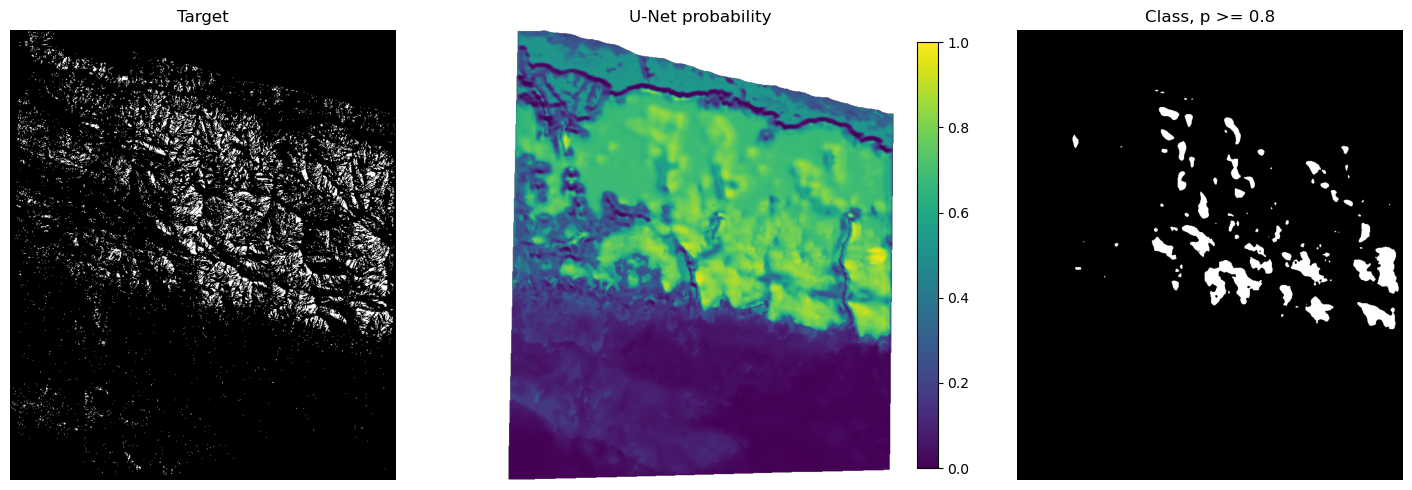

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(Y, cmap="gray")
axes[0].set_title("Target")

im = axes[1].imshow(prob, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("U-Net probability")
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(unet_class, cmap="gray")
axes[2].set_title(f"Class, p >= {PROB_THRESHOLD}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()